# TalentGuard — Notebook 03: Modelado de Machine Learning

**Proyecto:** TalentGuard: Sistema Inteligente para la Predicción del Riesgo de Rotación de Empleados  
**Autor:** Nicolas Gomez  
**Objetivo:** Entrenar, comparar y seleccionar el mejor modelo de clasificación binaria para predecir `Attrition`.

---

## Índice
1. Importaciones y configuración
2. Carga de datos procesados
3. Pipeline de preprocesamiento (escalado)
4. Entrenamiento y comparación de modelos
5. Evaluación detallada del mejor modelo
6. Serialización del modelo final
7. Guardado de métricas en model_metadata.json
8. Resumen

---
## 1. Importaciones y Configuración

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from datetime import date

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

RANDOM_STATE = 42

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas')

Librerías cargadas


---
## 2. Carga de Datos Procesados

In [20]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print(f'\nDistribución en train — No: {(y_train==0).sum()} | Yes: {(y_train==1).sum()}')
print(f'Distribución en test  — No: {(y_test==0).sum()}  | Yes: {(y_test==1).sum()}')

X_train: (1176, 43) | y_train: (1176,)
X_test:  (294, 43)  | y_test:  (294,)

Distribución en train — No: 986 | Yes: 190
Distribución en test  — No: 247  | Yes: 47


---
## 3. Pipeline de Preprocesamiento

Se usa `sklearn.pipeline.Pipeline` para encadenar el escalado con cada modelo.  
El `StandardScaler` se **ajusta solo sobre `X_train`** y se aplica sobre `X_test`, evitando data leakage.

In [21]:
# Los pipelines se definen junto con cada modelo en la sección 4.
# Aquí verificamos que no queden NaN antes de entrenar.
print(f'NaN en X_train: {X_train.isnull().sum().sum()}')
print(f'NaN en X_test:  {X_test.isnull().sum().sum()}')
print('Sin valores faltantes')

NaN en X_train: 0
NaN en X_test:  0
Sin valores faltantes


---
## 4. Entrenamiento y Comparación de Modelos

Se comparan dos algoritmos:

| Modelo | Justificación |
|---|---|
| **Logistic Regression** | Modelo base interpretable, rápido, buen punto de referencia para clasificación binaria. |
| **Random Forest** | Modelo de ensamble robusto, maneja bien variables mixtas y no requiere supuestos de linealidad. |

Ambos usan `class_weight='balanced'` para compensar el desbalance 84% / 16% en la variable `Attrition`.

In [22]:
# Definición de modelos en pipelines
modelos = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ])
}

print('Modelos definidos')

Modelos definidos


In [23]:
# Entrenamiento y evaluación sobre test
resultados = {}

for nombre, pipeline in modelos.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    resultados[nombre] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'f1_macro':  round(f1_score(y_test, y_pred, average='macro'), 4),
        'f1_yes':    round(f1_score(y_test, y_pred, pos_label=1), 4),
        'precision': round(precision_score(y_test, y_pred, average='macro'), 4),
        'recall':    round(recall_score(y_test, y_pred, average='macro'), 4),
        'roc_auc':   round(roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1]), 4),
    }
    print(f'{nombre} — F1-macro: {resultados[nombre]["f1_macro"]} | F1-Yes: {resultados[nombre]["f1_yes"]} | AUC: {resultados[nombre]["roc_auc"]}')

Logistic Regression — F1-macro: 0.6611 | F1-Yes: 0.4733 | AUC: 0.7986
Random Forest — F1-macro: 0.6135 | F1-Yes: 0.3243 | AUC: 0.7793


In [24]:
# Tabla comparativa
tabla = pd.DataFrame({
    nombre: {
        'Accuracy':    m['accuracy'],
        'F1-macro':    m['f1_macro'],
        'F1-Yes':      m['f1_yes'],
        'Precision':   m['precision'],
        'Recall':      m['recall'],
        'ROC-AUC':     m['roc_auc'],
    }
    for nombre, m in resultados.items()
}).T

print('Comparación de modelos sobre conjunto de TEST:')
tabla

Comparación de modelos sobre conjunto de TEST:


,Accuracy,F1-macro,F1-Yes,Precision,Recall,ROC-AUC
Logistic Regression,0.7653,0.6611,0.4733,0.6464,0.7225,0.7986
Random Forest,0.8299,0.6135,0.3243,0.6567,0.5973,0.7793


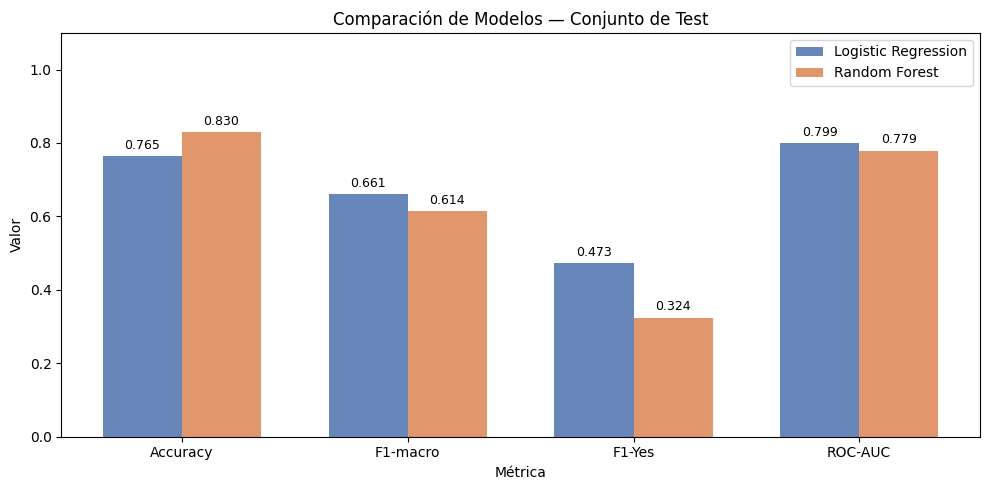

Gráfico guardado en charts/


In [25]:
# Visualización comparativa
metricas_plot = ['Accuracy', 'F1-macro', 'F1-Yes', 'ROC-AUC']
x = np.arange(len(metricas_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
nombres = list(resultados.keys())
valores_lr = [tabla.loc[nombres[0], m] for m in metricas_plot]
valores_rf = [tabla.loc[nombres[1], m] for m in metricas_plot]

bars1 = ax.bar(x - width/2, valores_lr, width, label=nombres[0], color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, valores_rf, width, label=nombres[1], color='#DD8452', alpha=0.85)

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_title('Comparación de Modelos — Conjunto de Test')
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('../charts/fig_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en charts/')

---
## 5. Evaluación Detallada del Mejor Modelo

**Criterio de selección:** F1-macro sobre el conjunto de test.  
El F1-macro fue definido en la Entrega 1 como métrica principal por el desbalance de clases.

In [26]:
# Selección automática del mejor modelo por F1-macro
mejor_nombre = max(resultados, key=lambda k: resultados[k]['f1_macro'])
mejor = resultados[mejor_nombre]

print(f'Mejor modelo: {mejor_nombre}')
print(f'F1-macro:     {mejor["f1_macro"]}')
print(f'F1-Yes:       {mejor["f1_yes"]}')
print(f'ROC-AUC:      {mejor["roc_auc"]}')

Mejor modelo: Logistic Regression
F1-macro:     0.6611
F1-Yes:       0.4733
ROC-AUC:      0.7986


In [27]:
# Reporte de clasificación completo
print(f'Classification Report — {mejor_nombre}\n')
print(classification_report(
    y_test, mejor['y_pred'],
    target_names=['No abandona (0)', 'Abandona (1)']
))

Classification Report — Logistic Regression

                 precision    recall  f1-score   support

No abandona (0)       0.92      0.79      0.85       247
   Abandona (1)       0.37      0.66      0.47        47

       accuracy                           0.77       294
      macro avg       0.65      0.72      0.66       294
   weighted avg       0.84      0.77      0.79       294



### Análisis del F1-Yes y el trade-off negocio / modelo

**¿Por qué el F1-Yes (0.47) es estructuralmente más bajo que el F1-macro (0.66)?**

El F1-Yes mide exclusivamente la capacidad del modelo para identificar empleados que *sí* abandonan (clase minoritaria, 16.1% del dataset). Con solo 47 casos reales de abandono en el conjunto de test, cada predicción incorrecta tiene un impacto desproporcionado sobre la métrica: un solo falso negativo adicional puede reducir el recall en más de 2 puntos porcentuales. El F1-macro promedia el rendimiento sobre ambas clases, por lo que la clase mayoritaria (84%) amortigua los errores en la minoritaria. Esta brecha entre F1-macro y F1-Yes es estructural en datasets desbalanceados — no es una falla del modelo, es una consecuencia matemática del desbalance 84/16.

**¿Qué hace `class_weight='balanced'`?**

Sin corrección, el modelo aprendería a predecir "No abandona" casi siempre y obtendría un accuracy del 84% sin detectar ningún caso real de riesgo. `class_weight='balanced'` penaliza más los errores sobre la clase minoritaria durante el entrenamiento, forzando al modelo a priorizar el **recall de la clase Yes**: prefiere equivocarse prediciendo abandono cuando no lo hay (falso positivo) antes que perder un caso real de abandono (falso negativo).

El resultado concreto en el reporte:

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| No abandona (0) | 0.92 | 0.79 | 0.85 |
| Abandona (1) | 0.37 | **0.66** | 0.47 |

El recall de 0.66 en la clase Yes significa que el modelo detecta 2 de cada 3 empleados que realmente van a renunciar.

**¿Por qué ese trade-off es correcto en el contexto de RRHH?**

En retención de talento, los costos de los dos tipos de error son asimétricos:

- **Falso negativo** (no detectar a alguien que va a renunciar): el empleado se va, la empresa pierde el conocimiento acumulado, incurre en costos de reemplazo (estimados entre 50% y 200% del salario anual) y no tuvo oportunidad de intervenir.
- **Falso positivo** (marcar como riesgo a alguien que no va a renunciar): el área de RRHH agenda una conversación de seguimiento innecesaria — costo bajo, sin consecuencias irreversibles.

Maximizar recall (minimizar falsos negativos) es la estrategia correcta para este dominio. El trade-off entre precision baja y recall alto no es un defecto del modelo: es la configuración óptima para el objetivo de negocio.

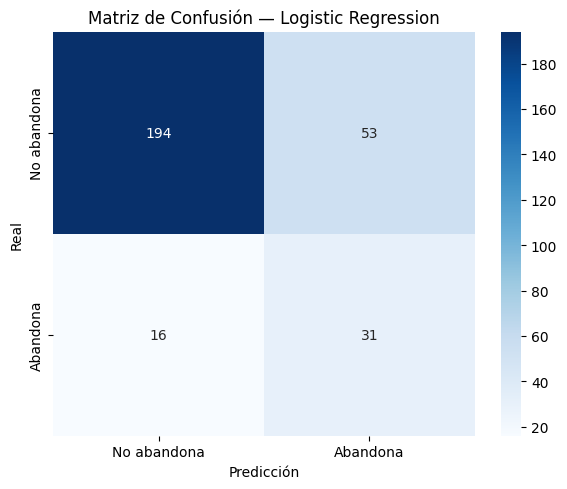

Gráfico guardado


In [28]:
# Matriz de confusión
cm = confusion_matrix(y_test, mejor['y_pred'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No abandona', 'Abandona'],
    yticklabels=['No abandona', 'Abandona'],
    ax=ax
)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión — {mejor_nombre}')
plt.tight_layout()
plt.savefig('../charts/fig_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado')

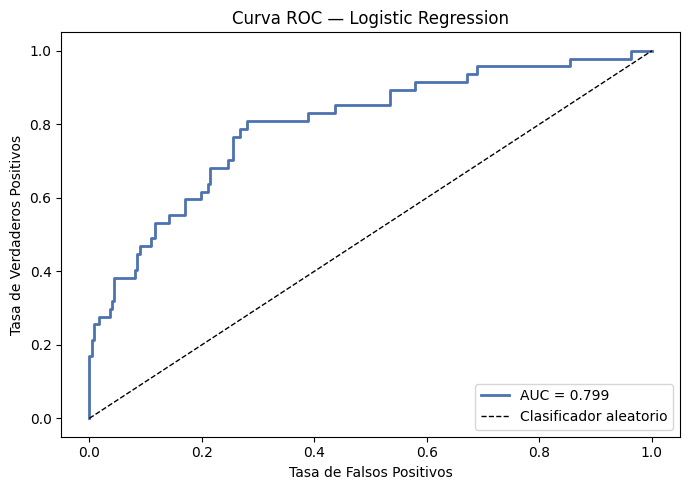

Gráfico guardado


In [29]:
# Curva ROC
y_prob = mejor['pipeline'].predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#4C72B0', lw=2,
        label=f'AUC = {mejor["roc_auc"]:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title(f'Curva ROC — {mejor_nombre}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../charts/fig_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado')

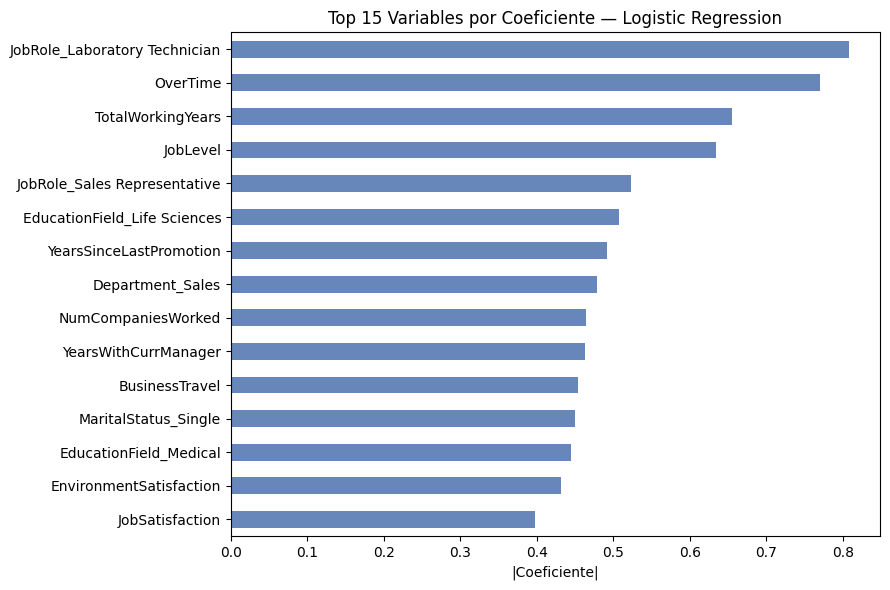

Gráfico guardado


In [30]:
# Importancia de variables (solo si el mejor modelo es Random Forest)
clf = mejor['pipeline'].named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importancias = pd.Series(
        clf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    importancias.plot(kind='barh', ax=ax, color='#4C72B0', alpha=0.85)
    ax.invert_yaxis()
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 15 Variables más Importantes — {mejor_nombre}')
    plt.tight_layout()
    plt.savefig('../charts/fig_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico guardado')
else:
    # Coeficientes para Logistic Regression
    coefs = pd.Series(
        np.abs(clf.coef_[0]),
        index=X_train.columns
    ).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    coefs.plot(kind='barh', ax=ax, color='#4C72B0', alpha=0.85)
    ax.invert_yaxis()
    ax.set_xlabel('|Coeficiente|')
    ax.set_title(f'Top 15 Variables por Coeficiente — {mejor_nombre}')
    plt.tight_layout()
    plt.savefig('../charts/fig_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico guardado')

---
## 6. Serialización del Modelo Final

> ⚠️ Serializar dentro del entorno virtual activo garantiza que la versión de scikit-learn sea la misma al cargar en Streamlit.

In [31]:
ruta_modelo = MODELS_DIR / 'modelo_final.pkl'
joblib.dump(mejor['pipeline'], ruta_modelo)

# Verificación de carga
modelo_verificado = joblib.load(ruta_modelo)
y_pred_verificado = modelo_verificado.predict(X_test)
f1_verificado = f1_score(y_test, y_pred_verificado, average='macro')

print(f'Modelo serializado en: {ruta_modelo}')
print(f'Verificación — F1-macro tras recarga: {f1_verificado:.4f}')
print(f'Tipo del objeto cargado: {type(modelo_verificado)}')

Modelo serializado en: ../models/modelo_final.pkl
Verificación — F1-macro tras recarga: 0.6611
Tipo del objeto cargado: <class 'sklearn.pipeline.Pipeline'>


---
## 7. Guardado de Métricas en model_metadata.json

In [32]:
metadata = {
    "modelo": mejor_nombre,
    "version": "1.0",
    "fecha_entrenamiento": str(date.today()),
    "metrica_principal": "f1_score_macro",
    "valor_metrica": mejor['f1_macro'],
    "f1_yes": mejor['f1_yes'],
    "accuracy": mejor['accuracy'],
    "precision_macro": mejor['precision'],
    "recall_macro": mejor['recall'],
    "roc_auc": mejor['roc_auc'],
    "variables_entrada": X_train.columns.tolist(),
    "variable_objetivo": "Attrition",
    "n_features": X_train.shape[1],
    "train_size": X_train.shape[0],
    "test_size": X_test.shape[0],
    "class_weight": "balanced",
    "observaciones": f"Pipeline: StandardScaler + {mejor_nombre}. class_weight='balanced' para desbalance 84/16. random_state=42."
}

ruta_metadata = MODELS_DIR / 'model_metadata.json'
with open(ruta_metadata, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Métricas guardadas en: {ruta_metadata}')
print(json.dumps({k: v for k, v in metadata.items() if k != 'variables_entrada'}, indent=2))

Métricas guardadas en: ../models/model_metadata.json
{
  "modelo": "Logistic Regression",
  "version": "1.0",
  "fecha_entrenamiento": "2026-06-12",
  "metrica_principal": "f1_score_macro",
  "valor_metrica": 0.6611,
  "f1_yes": 0.4733,
  "accuracy": 0.7653,
  "precision_macro": 0.6464,
  "recall_macro": 0.7225,
  "roc_auc": 0.7986,
  "variable_objetivo": "Attrition",
  "n_features": 43,
  "train_size": 1176,
  "test_size": 294,
  "class_weight": "balanced",
  "observaciones": "Pipeline: StandardScaler + Logistic Regression. class_weight='balanced' para desbalance 84/16. random_state=42."
}


---
## 8. Resumen

| Aspecto | Detalle |
|---|---|
| Modelos comparados | Logistic Regression vs Random Forest |
| Criterio de selección | F1-macro sobre conjunto de test |
| Manejo del desbalance | `class_weight='balanced'` en ambos modelos |
| Escalado | `StandardScaler` dentro del Pipeline (ajustado solo en train) |
| Semilla | `random_state=42` en todos los componentes |
| Artefactos generados | `models/modelo_final.pkl`, `models/model_metadata.json` |
| Gráficos generados | Comparación de modelos, matriz de confusión, curva ROC, importancia de variables |

**El modelo final responde directamente la pregunta analítica formulada en la Entrega 1:**  
*¿Es posible clasificar el riesgo de abandono voluntario (Attrition: Yes/No) de un empleado a partir de variables como satisfacción laboral, horas extra, balance vida-trabajo, antigüedad e ingresos mensuales?*

El modelo serializado en `models/modelo_final.pkl` será cargado directamente por el dashboard Streamlit (`app_final.py`) sin reentrenamiento en tiempo de ejecución.